In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests 
from bs4 import BeautifulSoup

In [73]:
df = pd.read_csv('data.csv')
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


In [11]:
df.describe()

,Дата,Склад,Количество
count,301355,301355.000000,301355.000000
mean,2018-05-03 18:58:36.652453632,2.900652,2.951559
min,2018-01-04 00:00:00,1.000000,0.000000
25%,2018-03-03 00:00:00,2.000000,1.000000
50%,2018-05-04 00:00:00,3.000000,2.000000
75%,2018-07-04 00:00:00,4.000000,4.000000
max,2018-08-31 00:00:00,5.000000,200.000000
std,NaN,1.352221,2.998154


Сразу переведем столбец "Дата" в правильный формат

In [7]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [8]:
df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


Сгруппируйте данные по дате, посчитайте количество продаж

In [13]:
grouped_df = (df.groupby('Дата').agg({'Количество': 'sum'}).reset_index())

Вывести несколько первых строк сгруппированных данных

In [14]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

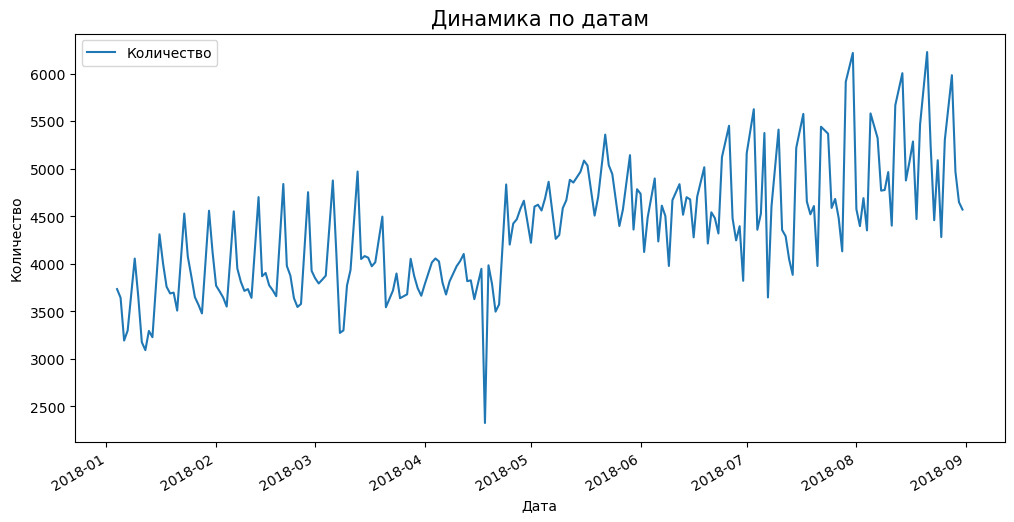

In [18]:
grouped_df.plot(x='Дата', y='Количество', figsize=(12, 6))
plt.title('Динамика по датам', fontsize=15)
plt.ylabel('Количество')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике видно, что со временем количество в целом растёт. В начале значения ниже, а ближе к концу периода они становятся заметно больше.
Значения постоянно скачут вверх-вниз, но это нормально — так происходит почти каждый день. При этом со временем эти скачки становятся сильнее. Есть один резкий провал в районе конца апреля — он сильно выбивается из общей картины, скорее всего это ошибка, сбой или какой-то особый день. В целом можно сказать, что показатель увеличивается, но ведёт себя неравномерно, без ровной линии.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [20]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [22]:
filtered_df = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Дата'].dt.weekday == 2)
]

In [24]:
filtered_df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество
191165,2018-06-06,3,address_206,product_0,2
191166,2018-06-06,3,address_206,product_1,4
191167,2018-06-06,3,address_206,product_2,4
191168,2018-06-06,3,address_206,product_3,2
191169,2018-06-06,3,address_206,product_4,1


In [28]:
top_product = (
    filtered_df
    .groupby('Номенклатура')['Количество'].sum()
    .sort_values(ascending=False).head(1))

In [29]:
top_product.head()

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [71]:
url = "https://rp5.ru/Архив_погоды_в_Астане"

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

table = soup.find('table', id='archiveTable')

df_weather_raw = pd.read_html(str(table))[0]
df_weather = df_weather_raw.iloc[1:].copy()
# [Беру первые 2 столбца, где дата и температура. Дальше я не знаю что за данные]
df_weather = df_weather[[0, 2]]
df_weather.columns = ['datetime_str', 'T']
df_weather['T'] = pd.to_numeric(df_weather['T'], errors='coerce')

df_weather['Дата'] = pd.to_datetime(
    df_weather['datetime_str'].str.extract(r'(\d{4}г\.\s*\d{1,2}\s*[а-яё]+\b)')[0],
    format='%Yг. %d %B',
    errors='coerce',
    dayfirst=True
)

weather_daily = df_weather.groupby('Дата')['T'].mean().reset_index()

print("Средняя температура по дням:")
print(weather_daily.head(10))

Средняя температура по дням:
Empty DataFrame
Columns: [Дата, T]
Index: []


/var/folders/rw/jt5z26zj3tj189nxk42v1fch0000gp/T/ipykernel_57386/1557985878.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_weather_raw = pd.read_html(str(table))[0]


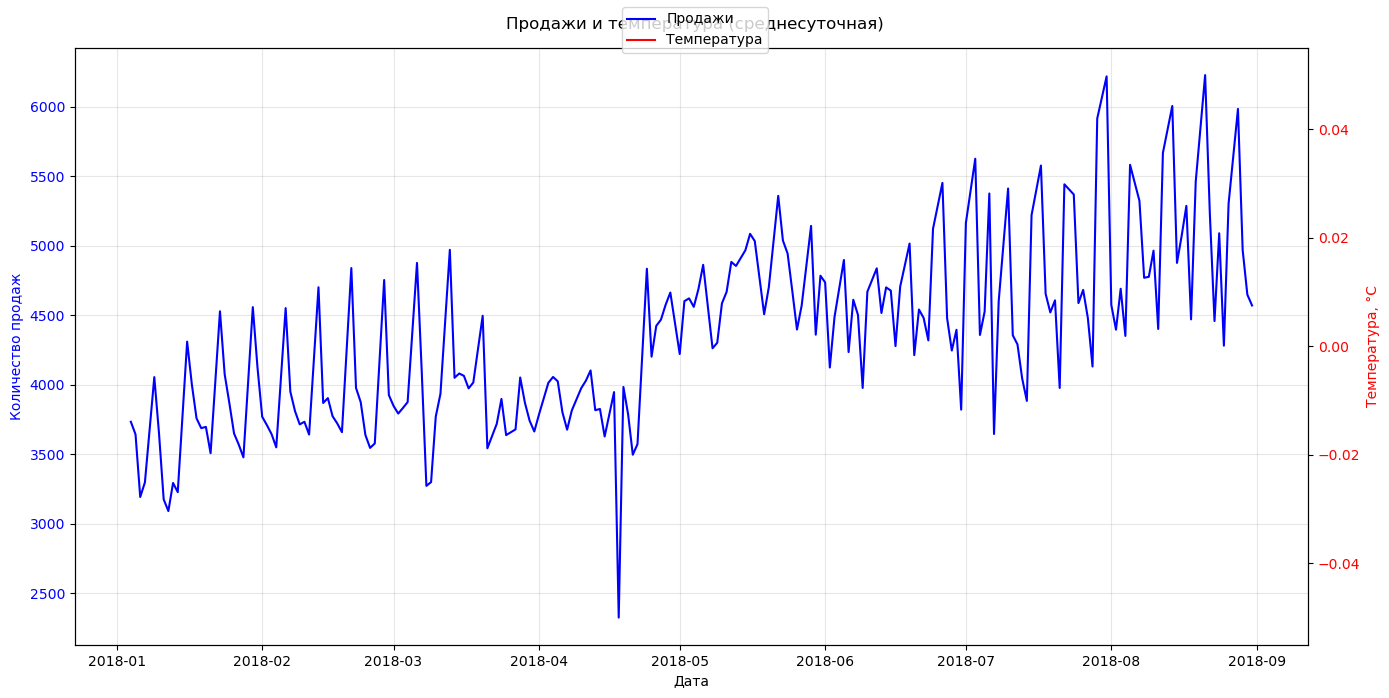

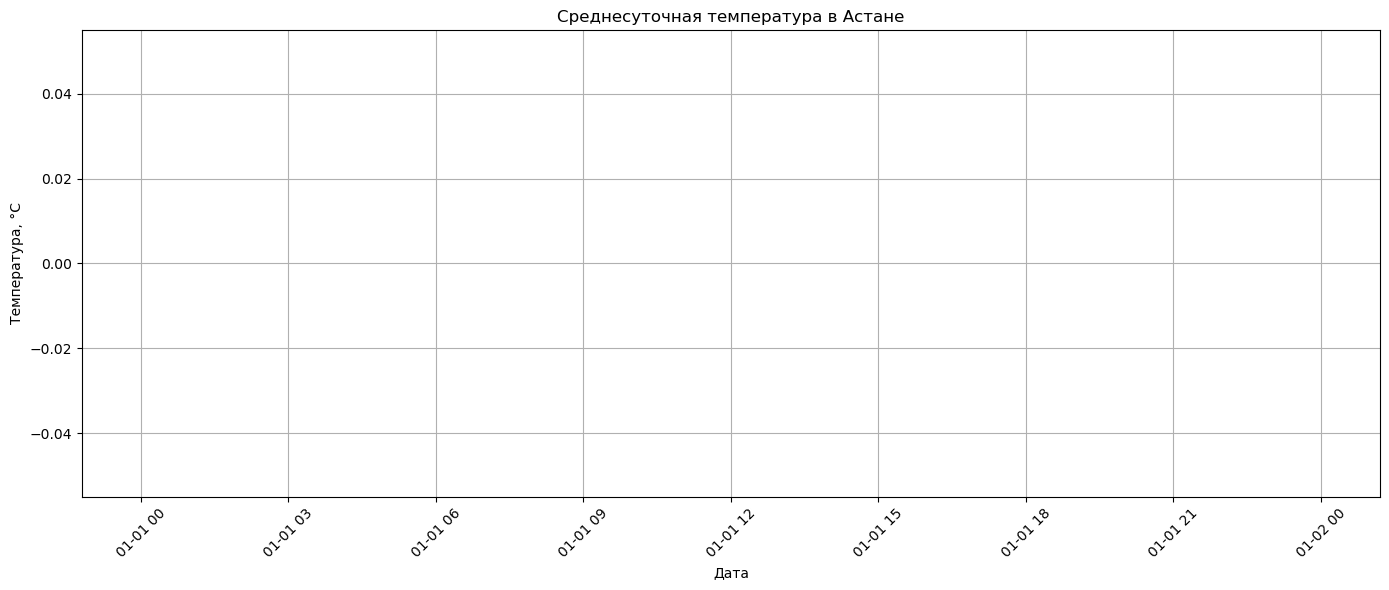

In [72]:
merged_df = grouped_df.merge(weather_daily, on='Дата', how='left')

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(merged_df['Дата'], merged_df['Количество'], color='blue', label='Продажи')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], color='red', label='Температура')
ax2.set_ylabel('Температура, °C', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.suptitle('Продажи и температура (среднесуточная)')
fig.legend(loc='upper center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# График 2 — только температура
plt.figure(figsize=(14, 6))
plt.plot(weather_daily['Дата'], weather_daily['T'], color='red', marker='o')
plt.title('Среднесуточная температура в Астане')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()